# ftir_39 — Leakage-safe PLS transfer and applicability-domain audit

## tl;dr

The source-only applicability domain catches severe spectral extrapolation for the
derivative-space common and Delhi candidates (38–64% of locked targets outside the 95%
source envelope), but the Addis OCEC/AIRSpec winner places **all** Addis and Delhi holdouts
inside while still missing Addis by RMSE **2.81 µg m⁻³**. Domain distance is therefore a
useful warning, not a guarantee of calibration validity. This complements ftir_36: all
components and di-PLS penalties were selected without target labels, yet unsupervised
covariance alignment did not create a universal calibration. Deployment should require
both source-grouped validation and an applicability flag, with response validation kept as
a separate gate.

## Context & Methods

This notebook reuses the frozen ftir_36 cohorts and locked ordinary-PLS predictions. For
each configuration, the same site-disjoint source split is reconstructed. A scaler and PCA
model are fitted on source training spectra only; the untouched source-site holdout defines
empirical reference distributions for Hotelling-like T² and Q residual. Target labels are
joined only after these distances and 95% flags are computed.

### Key assumptions and leakage controls

- No target HIPS value participates in cohort choice, component choice, centering,
  thresholding, PCA fitting, or source reference percentiles.
- The domain rule is the union of T² and Q above the 95th percentile of untouched source
  sites; this is deliberately conservative and configuration-specific.
- Applicability is not accuracy. A target may be spectrally in-domain while its
  response-generating relationship differs.

In [1]:
%matplotlib inline
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

sys.path.insert(0, './scripts')
sys.path.insert(0, '../ftir_hips_chem/scripts')
from plotting import apply_default_style
from theory_test_suite import applicability_domain_analysis

apply_default_style()
ROOT = Path('.')
OUT = ROOT / 'output/tables/ftir39'
PLOTS = ROOT / 'output/plots/ftir39'
OUT.mkdir(parents=True, exist_ok=True)
PLOTS.mkdir(parents=True, exist_ok=True)

## Data

### Provenance and data quality

The frozen protocol is the provenance contract. `target_labels_opened: false` was written
before the locked reveal in ftir_36. The current audit does not reselect any model.

In [2]:
frozen = pd.read_csv(ROOT / 'output/tables/ftir36/frozen_protocol.csv')
outer = pd.read_csv(ROOT / 'output/tables/ftir36/outer_source_validation.csv')
locked = pd.read_csv(ROOT / 'output/tables/ftir36/locked_target_summary.csv')
display(frozen)
display(outer[outer['variant'].eq('ordinary_pls')].round(3))

,config,cohort,cutoff,spectra,n_source,n_source_train,n_source_outer_holdout,n_source_sites,n_features_binned,n_components,component_rule,selected_multiplier
0,addis_winner,ocec,440,airspec,440,387,53,105,251,5,first local minimum within one SE of global mi...,0.1
1,common_candidate,analogs,440,deriv2,440,334,106,116,341,15,first local minimum within one SE of global mi...,1.0
2,delhi_winner,analogs,530,deriv2,530,423,107,127,341,12,first local minimum within one SE of global mi...,1.0


,config,variant,n,slope,intercept,R2,RMSE_1to1,mean_bias,median_heuristic_lambda
0,addis_winner,ordinary_pls,53,0.957,-0.179,0.908,3.714,-0.466,3.736566e+08
6,common_candidate,ordinary_pls,106,0.756,1.119,0.842,1.412,0.040,1.548176e+12
12,delhi_winner,ordinary_pls,107,0.675,1.173,0.842,1.611,-0.297,1.377699e+12


## Results

In [3]:
per_filter, summary = applicability_domain_analysis()
display(summary.round(3))
per_filter.to_csv(OUT / 'locked_target_domain_per_filter.csv', index=False)
summary.to_csv(OUT / 'locked_target_domain_summary.csv', index=False)

,config,target,n,outside_source_95_pct,median_T2_source_percentile,median_Q_source_percentile,rho_domain_percentile_vs_abs_error,rho_p,RMSE_inside,RMSE_outside
0,addis_winner,addis_holdout,14,0.000,0.704,0.685,0.080,0.785,2.812,NaN
1,addis_winner,delhi_holdout,26,0.000,0.380,0.546,0.439,0.025,2.607,NaN
2,common_candidate,addis_holdout,14,50.000,0.949,0.944,0.648,0.012,2.952,3.402
3,common_candidate,delhi_holdout,26,38.462,0.888,0.944,0.313,0.119,1.771,2.656
4,delhi_winner,addis_holdout,14,64.286,0.921,0.963,0.154,0.599,2.648,3.095
5,delhi_winner,delhi_holdout,26,38.462,0.880,0.935,0.133,0.518,2.227,1.332


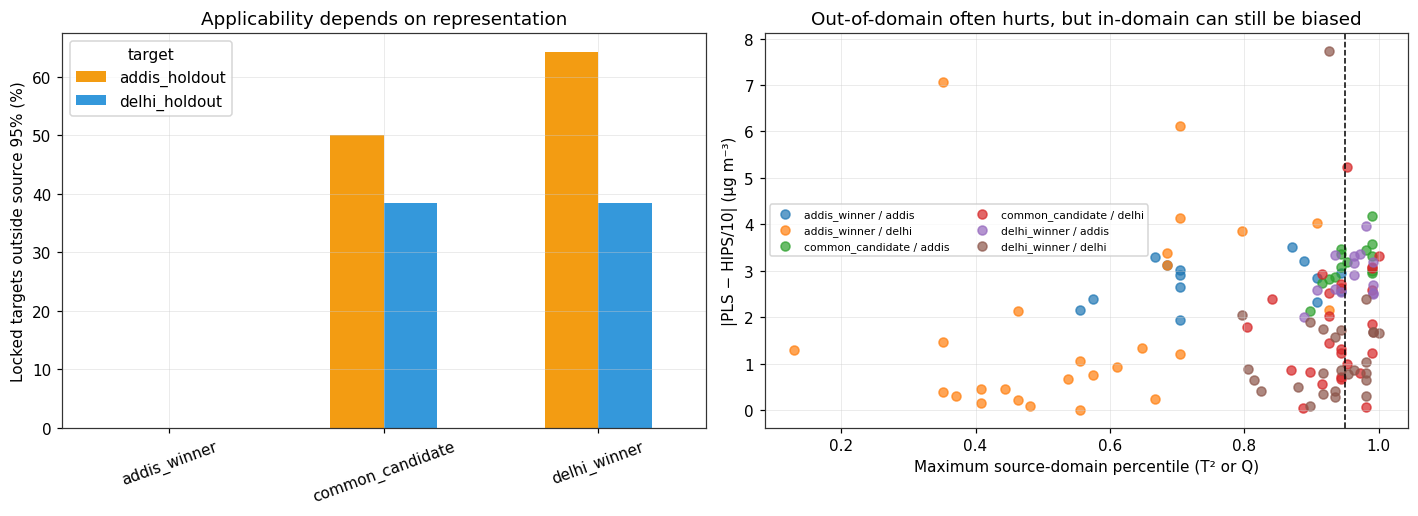

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
pivot = summary.pivot(index='config', columns='target', values='outside_source_95_pct')
pivot.plot.bar(ax=axes[0], color=['#F39C12', '#3498DB'])
axes[0].set(ylabel='Locked targets outside source 95% (%)', xlabel='',
            title='Applicability depends on representation')
axes[0].tick_params(axis='x', rotation=20)

plot_data = per_filter.copy()
plot_data['domain_percentile'] = plot_data[['T2_source_percentile', 'Q_source_percentile']].max(axis=1)
for (config, target), group in plot_data.groupby(['config', 'target']):
    axes[1].scatter(group['domain_percentile'], group['abs_error_ugm3'], s=35, alpha=.7,
                    label=f'{config} / {target.replace("_holdout", "")}')
axes[1].axvline(.95, color='black', ls='--', lw=1)
axes[1].set(xlabel='Maximum source-domain percentile (T² or Q)',
            ylabel='|PLS − HIPS/10| (µg m⁻³)',
            title='Out-of-domain often hurts, but in-domain can still be biased')
axes[1].legend(fontsize=7, ncol=2)

fig.tight_layout()
fig.savefig(PLOTS / 'pls_applicability_domain.png', bbox_inches='tight')
plt.show()

## Takeaways

- **Use two gates:** site-grouped source validation tests leakage/generalization;
  T²/Q tests whether a new spectrum resembles the calibrated domain. Neither substitutes
  for labeled target validation.
- **The Addis winner is the counterexample to “in-domain means valid.”** It is in-domain by
  both measures but retains a large response bias, consistent with conditional/response
  shift rather than pure covariate shift.
- **The derivative-space candidates need explicit flags.** A substantial fraction of their
  locked targets are outside the source envelope.
- **Do not tune thresholds on target errors.** These 95% rules remain source-only; the
  error plots are post hoc validation of the warning system, not threshold selection.